# EN3160 Assignment 01

## Intensity Transformations and Neighborhood Filtering

---

**Name:** R.A.C.D. Ranawaka    
**Index Number:** 230526A  
**GitHub Link:** https://github.com/chaniruranawaka/Intensity-Transformations-and-Neighborhood-Filtering


---

### Assignment Objective

This assignment investigates fundamental image processing techniques involving
intensity transformations and neighborhood filtering. The experiments explore
how different image enhancement and filtering techniques affect image
characteristics and visual quality.

### Q1. Intensity Transformation with Breakpoints

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_path = "data/input/q1.jpeg"

im = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if im is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

In [6]:
# Implementing the intensity transformation function
def intensity_transform(im, breakpoints):
    
    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]

    transformed = np.interp(
        im.astype(np.float32),
        input_values,
        output_values
    )

    transformed = np.clip(transformed, 0, 255)

    return transformed.astype(np.uint8)

In [7]:
# Different Breakpoint Configurations
breakpoints_1a = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
])

breakpoints_1 = np.array([
    [0,   0],
    [50,  25],
    [128, 128],
    [200, 230],
    [255, 255]
])

breakpoints_2 = np.array([
    [0,   20],
    [50,  55],
    [128, 140],
    [200, 220],
    [255, 255]
])

breakpoints_3 = np.array([
    [0,   0],
    [40,  65],
    [100, 145],
    [180, 220],
    [255, 255]
])

breakpoint_sets = {
    "Figure 1a": breakpoints_1a,
    "Custom 1": breakpoints_1,
    "Custom 2": breakpoints_2,
    "Custom 3": breakpoints_3
}

# Applying the intensity transformation to the image using different breakpoint configurations
transformed_images = {}

for name, breakpoints in breakpoint_sets.items():
    transformed_images[name] = intensity_transform(im, breakpoints)

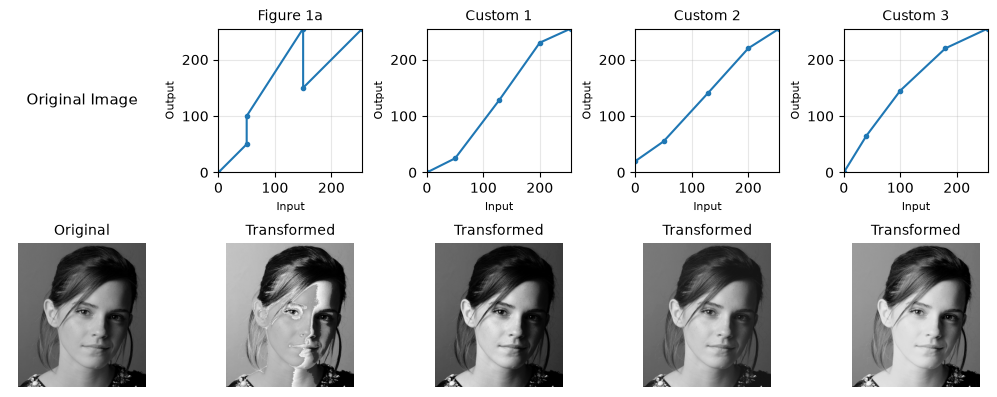

In [8]:
# Original image + intensity transformations
fig, axes = plt.subplots(
    2, 5,
    figsize=(10, 4)
)

# --------------------------------
# Original image
# --------------------------------

# Top-left: Original label
axes[0, 0].text(
    0.5, 0.5,
    "Original Image",
    ha="center",
    va="center",
    fontsize=11
)
axes[0, 0].axis("off")

# Bottom-left: Original image
axes[1, 0].imshow(
    im,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1, 0].set_title("Original", fontsize=10)
axes[1, 0].axis("off")


# --------------------------------
# Four transformations
# --------------------------------

for i, (name, breakpoints) in enumerate(breakpoint_sets.items(), start=1):

    # Intensity transformation graph
    ax = axes[0, i]

    ax.plot(
        breakpoints[:, 0],
        breakpoints[:, 1],
        marker="o",
        linewidth=1.5,
        markersize=3
    )

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Input", fontsize=8)
    ax.set_ylabel("Output", fontsize=8)

    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.grid(True, alpha=0.3)

    # Transformed image
    ax = axes[1, i]

    ax.imshow(
        transformed_images[name],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title("Transformed", fontsize=10)
    ax.axis("off")


plt.tight_layout(pad=0.8)
plt.show()

**Observation:** The intensity transformation function was implemented using different breakpoint configurations and applied to the grayscale input image. The resulting transformation curves demonstrate how modifying the input–output intensity relationship can enhance or alter different intensity ranges of the image.

### Q2. Intensity Transformation for Brain Tissue Enhancement

In [9]:
# Load the image
image_path_q2 = "data/input/q2.jpeg"

brain = cv2.imread(
    image_path_q2,
    cv2.IMREAD_GRAYSCALE
)

if brain is None:
    raise FileNotFoundError(f"Could not load image: {image_path_q2}")

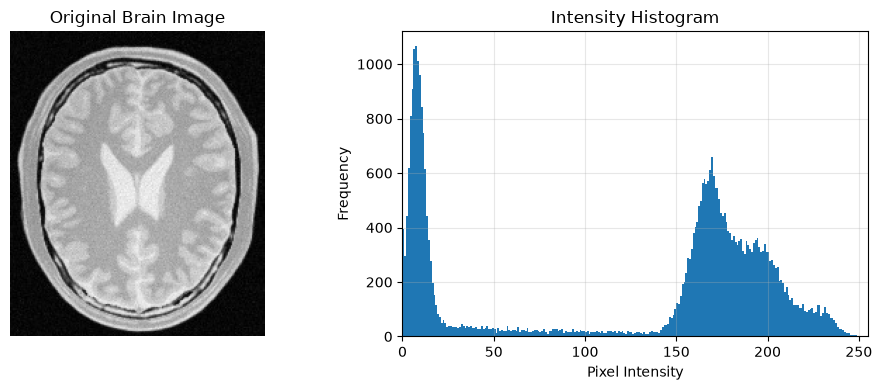

In [12]:
# Display the original brain image alongside its intensity histogram

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

# -------------------------------
# Original brain image
# -------------------------------

axes[0].imshow(
    brain,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[0].set_title("Original Brain Image")
axes[0].axis("off")


# -------------------------------
# Intensity histogram
# -------------------------------

axes[1].hist(
    brain.ravel(),
    bins=256,
    range=(0, 256)
)

axes[1].set_title("Intensity Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

axes[1].set_xlim(0, 255)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

**Observation:** 
The histogram shows a low-intensity region around **0–50**, corresponding mainly to the background, and a broad tissue distribution from approximately **135–251**. Visual inspection shows that **gray matter is prominent around 135–190**, while **white matter is prominent around 190–251**. These ranges are selected for the respective intensity transformations.


#### 2.(a) White Matter

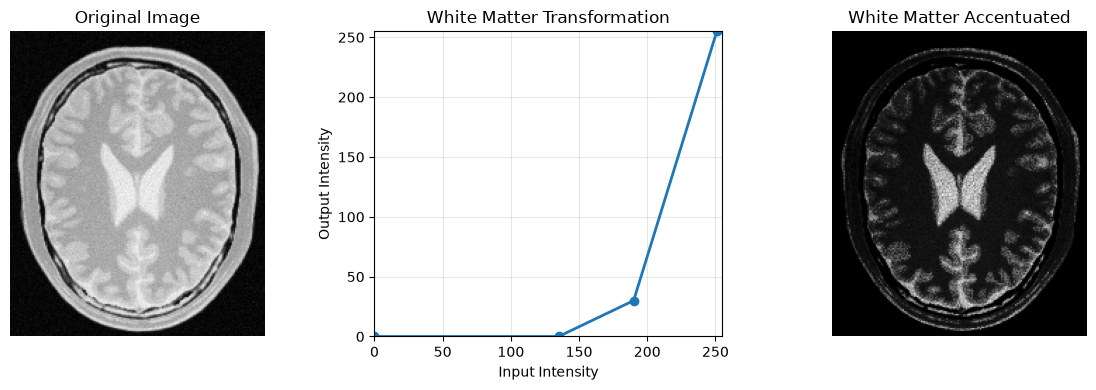

In [22]:
# Breakpoints for white matter enhancement
white_matter_breakpoints = np.array([
    [0,   0],
    [135, 0],
    [190, 30],
    [251, 255]
])

# Apply white matter intensity transformation
white_matter_enhanced = intensity_transform(
    brain,
    white_matter_breakpoints
)

# Display original image, transformation plot, and result
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4)
)

# Original image
axes[0].imshow(
    brain,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[0].set_title("Original Image")
axes[0].axis("off")


# Intensity transformation
axes[1].plot(
    white_matter_breakpoints[:, 0],
    white_matter_breakpoints[:, 1],
    marker="o",
    linewidth=2
)
axes[1].set_title("White Matter Transformation")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True, alpha=0.3)


# Transformed image
axes[2].imshow(
    white_matter_enhanced,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("White Matter Accentuated")
axes[2].axis("off")

plt.tight_layout()
plt.show()

#### 2.(b) Gray Matter

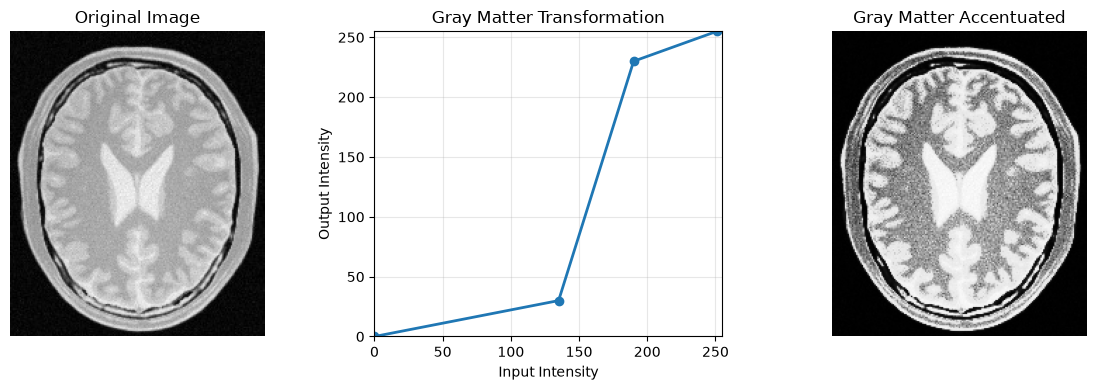

In [23]:
# Breakpoints for gray matter enhancement
gray_matter_breakpoints = np.array([
    [0,   0],
    [135, 30],
    [190, 230],
    [251, 255]
])

# Apply gray matter intensity transformation
gray_matter_enhanced = intensity_transform(
    brain,
    gray_matter_breakpoints
)

# Display original image, transformation plot, and result
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4)
)

# Original image
axes[0].imshow(
    brain,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[0].set_title("Original Image")
axes[0].axis("off")


# Intensity transformation
axes[1].plot(
    gray_matter_breakpoints[:, 0],
    gray_matter_breakpoints[:, 1],
    marker="o",
    linewidth=2
)
axes[1].set_title("Gray Matter Transformation")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True, alpha=0.3)


# Transformed image
axes[2].imshow(
    gray_matter_enhanced,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Gray Matter Accentuated")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Observation:** The piecewise-linear intensity transformations successfully accentuated the desired brain tissues. The 135–190 intensity range enhanced the visibility of gray matter, while the 190–251 range emphasized white matter by increasing the contrast within each selected intensity range.


### Q3. Gamma Correction

In [24]:
image_path_q3 = "data/input/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg"

image = cv2.imread(image_path_q3)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path_q3}")

* The image is converted from BGR to L* a* b* color space, and the L* plane is extracted for gamma correction.

In [25]:
# Convert BGR image to L*a*b* color space
lab = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2LAB
)

# Split into L*, a*, and b* planes
L, a, b = cv2.split(lab)

#### 3.(a) Apply gamma correction

In [34]:
# Gamma values to compare
gamma_values = [0.5, 0.7, 0.9, 1.0, 1.2]

gamma_results = {}

for gamma in gamma_values:

    # Normalize L* to [0, 1]
    L_normalized = L / 255.0

    # Apply gamma correction
    L_gamma = np.power(
        L_normalized,
        gamma
    )

    # Convert back to 8-bit
    L_corrected = np.uint8(
        L_gamma * 255
    )

    # Store result
    gamma_results[gamma] = L_corrected

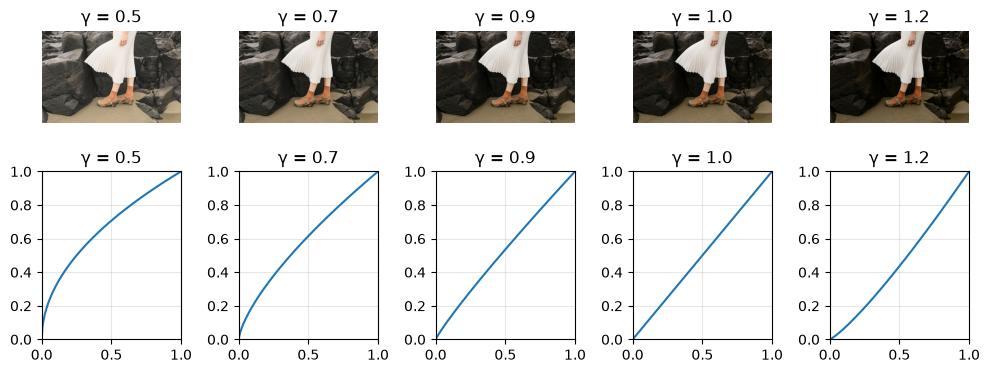

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

r = np.linspace(0, 1, 256)

for i, gamma in enumerate(gamma_values):

    # Corrected image
    lab_temp = cv2.merge([gamma_results[gamma], a, b])
    corrected = cv2.cvtColor(lab_temp, cv2.COLOR_LAB2BGR)

    axes[0, i].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"γ = {gamma}")
    axes[0, i].axis("off")

    # Gamma transformation
    axes[1, i].plot(r, r**gamma)
    axes[1, i].set_title(f"γ = {gamma}")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** The results show that decreasing γ below 1 increases the brightness of the image, while increasing γ above 1 produces a darker result. The transformation curves also show this change in the mapping of L* intensity values.

* Among the tested values, γ = 0.7 provides the most suitable enhancement for the given image.

#### 3.(b) Histograms of original and gamma corrected image

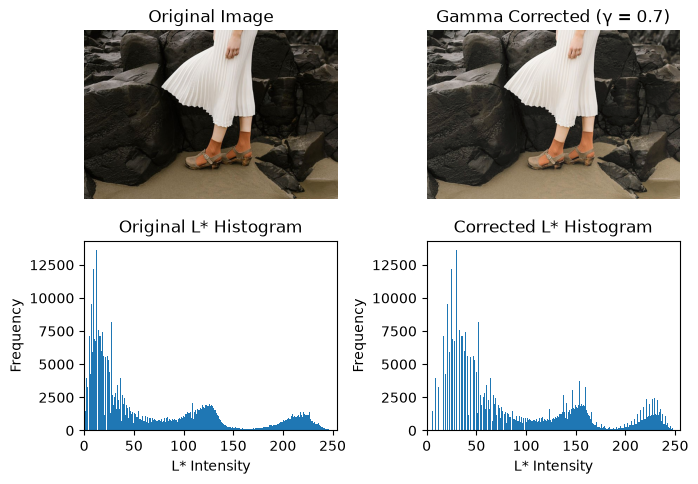

In [36]:
gamma = 0.7

# Apply gamma correction to L*
L_corrected = np.uint8(
    (L / 255.0) ** gamma * 255
)

# Reconstruct L*a*b*
lab_corrected = cv2.merge([
    L_corrected,
    a,
    b
])

# Convert back to BGR
corrected_image = cv2.cvtColor(
    lab_corrected,
    cv2.COLOR_LAB2BGR
)

# Display images and histograms
fig, axes = plt.subplots(
    2, 2,
    figsize=(7, 5)
)

# Original image
axes[0, 0].imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Gamma corrected image
axes[0, 1].imshow(
    cv2.cvtColor(corrected_image, cv2.COLOR_BGR2RGB)
)
axes[0, 1].set_title("Gamma Corrected (γ = 0.7)")
axes[0, 1].axis("off")

# Original L* histogram
axes[1, 0].hist(
    L.ravel(),
    bins=256,
    range=(0, 256)
)
axes[1, 0].set_title("Original L* Histogram")
axes[1, 0].set_xlabel("L* Intensity")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_xlim(0, 255)

# Corrected L* histogram
axes[1, 1].hist(
    L_corrected.ravel(),
    bins=256,
    range=(0, 256)
)
axes[1, 1].set_title("Corrected L* Histogram")
axes[1, 1].set_xlabel("L* Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

**Observation:** With **γ = 0.7**, the darker L* intensity values are expanded, resulting in a brighter image. The corrected histogram shows the corresponding shift of the L* intensity distribution toward higher values.


### Q4. Vibrance Enhancement

In [ ]:
# Load image
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.441.jpeg")

#### 4.(a) Split the Image into Hue, Saturation and Value Planes

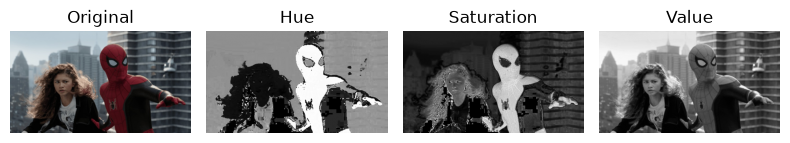

In [43]:
# Convert BGR to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Split into H, S, V planes
H, S, V = cv2.split(hsv)

# Display original and HSV planes
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(H, cmap="gray")
axes[1].set_title("Hue")
axes[1].axis("off")

axes[2].imshow(S, cmap="gray")
axes[2].set_title("Saturation")
axes[2].axis("off")

axes[3].imshow(V, cmap="gray")
axes[3].set_title("Value")
axes[3].axis("off")

plt.tight_layout()
plt.show()

#### 4.(b) Apply the intensity transformation

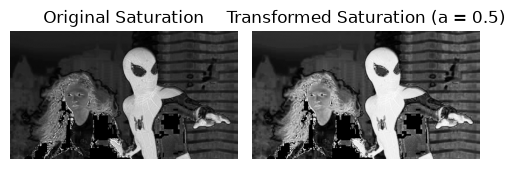

In [44]:
sigma = 70
a = 0.5

# Apply transformation to saturation plane
x = S.astype(np.float32)

S_new = np.minimum(
    x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
    255
).astype(np.uint8)

# Display original and transformed saturation
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))

axes[0].imshow(S, cmap="gray")
axes[0].set_title("Original Saturation")
axes[0].axis("off")

axes[1].imshow(S_new, cmap="gray")
axes[1].set_title(f"Transformed Saturation (a = {a})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 4.(c) Adjust a

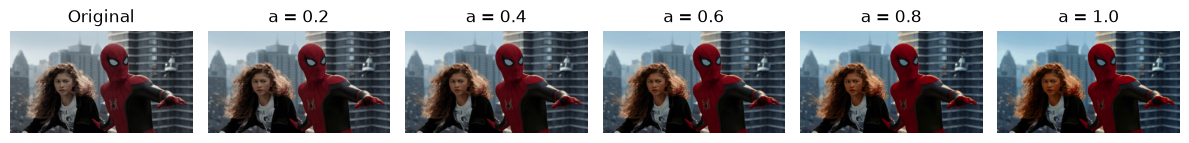

In [46]:
a_values = [0.2, 0.4, 0.6, 0.8, 1.0]
sigma = 70

results = []

for a in a_values:
    x = S.astype(np.float32)

    S_new = np.minimum(
        x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
        255
    ).astype(np.uint8)

    hsv_new = cv2.merge([H, S_new, V])
    result = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)

    results.append((a, result))

# Display original + results
fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))

# Original image
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

# Different a values
for ax, (a, result) in zip(axes[1:], results):
    ax.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    ax.set_title(f"a = {a}")
    ax.axis("off")

plt.tight_layout()
plt.show()

* After comparing several values of (a), (a = 0.4) was selected as it provided a visually pleasing increase in image vibrance while maintaining natural-looking colors.

#### 4.(d) Recombine the Three Planes

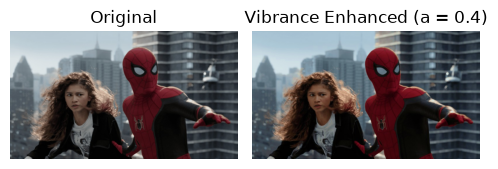

In [48]:
a = 0.4
sigma = 70

# Transform saturation plane
x = S.astype(np.float32)

S_new = np.minimum(
    x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
    255
).astype(np.uint8)

# Recombine H, transformed S, and V
hsv_enhanced = cv2.merge([H, S_new, V])

# Convert back to BGR
vibrance_image = cv2.cvtColor(
    hsv_enhanced,
    cv2.COLOR_HSV2BGR
)

# Display original and enhanced images
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(vibrance_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("Vibrance Enhanced (a = 0.4)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 4.(e) Final Result

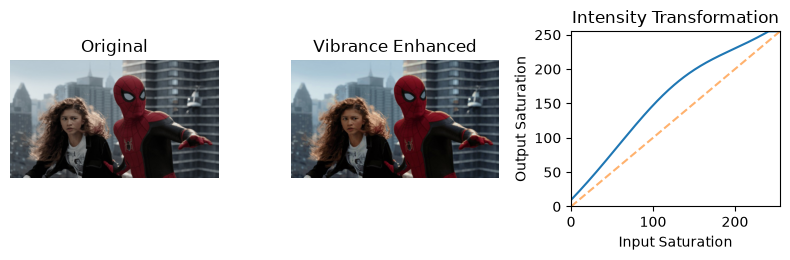

In [49]:
# Intensity transformation curve
x = np.arange(256)

transformation = np.minimum(
    x + a * 128 * np.exp(-(x - 128)**2 / (2 * sigma**2)),
    255
)

# Display final results
fig, axes = plt.subplots(1, 3, figsize=(8, 2.7))

# Original
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

# Vibrance enhanced
axes[1].imshow(cv2.cvtColor(vibrance_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("Vibrance Enhanced")
axes[1].axis("off")

# Transformation curve
axes[2].plot(x, transformation)
axes[2].plot(x, x, "--", alpha=0.6)
axes[2].set_title("Intensity Transformation")
axes[2].set_xlabel("Input Saturation")
axes[2].set_ylabel("Output Saturation")
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)

plt.tight_layout()
plt.show()

**Observation:** The saturation enhancement with **\(a=0.4\)** increased the vibrance of the image while maintaining a visually natural appearance. The nonlinear transformation primarily increases saturation around the middle intensity range while limiting the output to 255.


### Q5. Histogram Equalization

In [50]:
def histogram_equalization(image):
    # Calculate histogram
    hist = np.bincount(image.ravel(), minlength=256)

    # Calculate cumulative distribution function
    cdf = hist.cumsum()

    # Normalize CDF
    cdf_min = cdf[cdf > 0][0]
    cdf_normalized = (cdf - cdf_min) * 255 / (cdf[-1] - cdf_min)

    # Create intensity mapping
    mapping = np.clip(cdf_normalized, 0, 255).astype(np.uint8)

    # Apply mapping
    equalized = mapping[image]

    return equalized

In [53]:
# Load image
image = cv2.imread("data/input/shells.tif")
imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# Apply custom histogram equalization
equalized_image = histogram_equalization(imageGray)

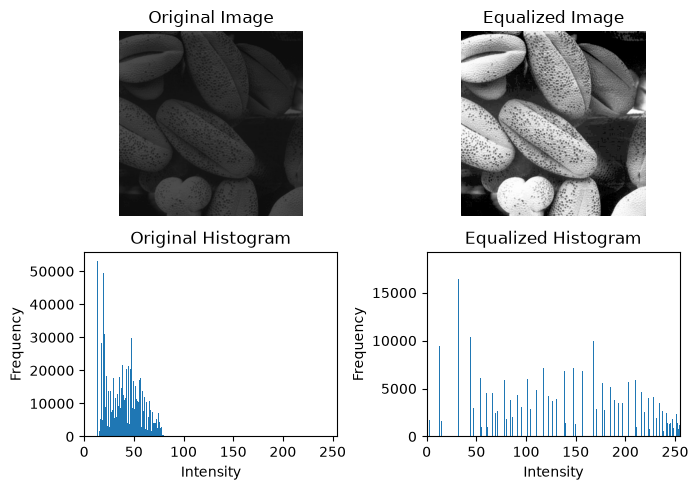

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5))

# Original image
axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Equalized image
axes[0, 1].imshow(equalized_image, cmap="gray")
axes[0, 1].set_title("Equalized Image")
axes[0, 1].axis("off")

# Original histogram
axes[1, 0].hist(image.ravel(), bins=256, range=(0, 256))
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_xlim(0, 255)

# Equalized histogram
axes[1, 1].hist(equalized_image.ravel(), bins=256, range=(0, 256))
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

**Observation:** Histogram equalization redistributed the image intensity values over a wider range, improving the overall contrast. The equalized histogram shows a more evenly distributed intensity range compared with the original histogram.


### Q6. Foreground-only histogram equalization

In [55]:
# Load image
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg")

#### 6.(a) Split into H, S, V planes

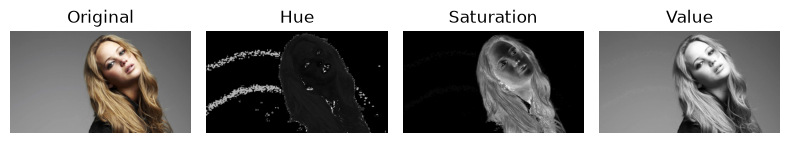

In [56]:
# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Split planes
H, S, V = cv2.split(hsv)

# Display original and HSV planes
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(H, cmap="gray")
axes[1].set_title("Hue")
axes[1].axis("off")

axes[2].imshow(S, cmap="gray")
axes[2].set_title("Saturation")
axes[2].axis("off")

axes[3].imshow(V, cmap="gray")
axes[3].set_title("Value")
axes[3].axis("off")

plt.tight_layout()
plt.show()

#### 6.(b) Foreground Mask

* The Saturation (S) plane was selected for thresholding because it provided the best separation between the foreground and background. A binary threshold was applied to obtain the foreground mask.

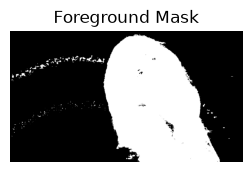

In [69]:
# Threshold the Saturation plane
threshold = 10

_, mask = cv2.threshold(
    S,
    threshold,
    255,
    cv2.THRESH_BINARY
)

# Display mask
plt.figure(figsize=(3, 3))
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")
plt.show()

#### 6.(c) Extract the Foreground and Compute Histogram

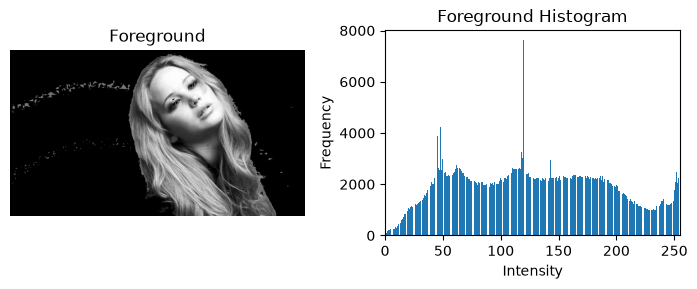

In [70]:
# Extract foreground using the mask
foreground = cv2.bitwise_and(
    V,
    V,
    mask=mask
)

# Compute foreground histogram
hist = np.bincount(
    foreground[mask > 0],
    minlength=256
)

# Display foreground and histogram
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].imshow(foreground, cmap="gray")
axes[0].set_title("Foreground")
axes[0].axis("off")

axes[1].bar(np.arange(256), hist)
axes[1].set_title("Foreground Histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

#### 6.(d) Cumulative Sum of the Histogram

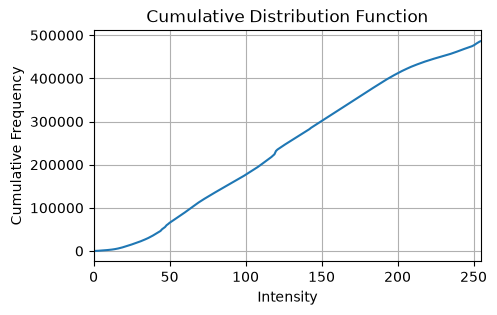

In [71]:
# Calculate cumulative distribution function
cdf = np.cumsum(hist)

# Display CDF
plt.figure(figsize=(5, 3))
plt.plot(cdf)
plt.title("Cumulative Distribution Function")
plt.xlabel("Intensity")
plt.ylabel("Cumulative Frequency")
plt.xlim(0, 255)
plt.grid()
plt.show()

#### 6.(e) Histogram Equalization of the Foreground

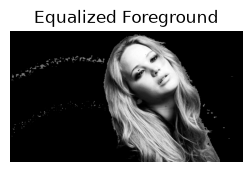

In [72]:
# Find the first non-zero CDF value
cdf_min = cdf[cdf > 0][0]

# Normalize CDF to 0-255
mapping = (
    (cdf - cdf_min) * 255 /
    (cdf[-1] - cdf_min)
)

mapping = np.clip(mapping, 0, 255).astype(np.uint8)

# Apply equalization only to foreground pixels
equalized_foreground = foreground.copy()

equalized_foreground[mask > 0] = mapping[
    foreground[mask > 0]
]

# Display equalized foreground
plt.figure(figsize=(3, 3))
plt.imshow(equalized_foreground, cmap="gray")
plt.title("Equalized Foreground")
plt.axis("off")
plt.show()

#### 6.(f) Combine Equalized Foreground with Background

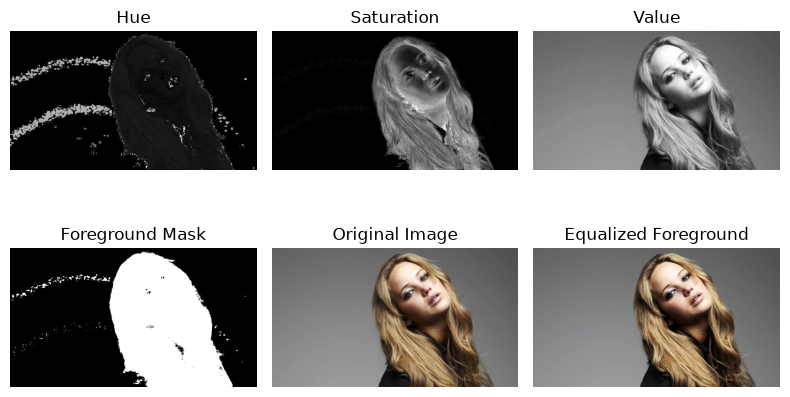

In [73]:
# Extract background
background = cv2.bitwise_and(
    V,
    V,
    mask=cv2.bitwise_not(mask)
)

# Combine background with equalized foreground
V_final = background + equalized_foreground

# Recombine HSV planes
hsv_final = cv2.merge([H, S, V_final])

# Convert back to BGR
result = cv2.cvtColor(
    hsv_final,
    cv2.COLOR_HSV2BGR
)

# Display required results
fig, axes = plt.subplots(2, 3, figsize=(8, 5))

axes[0, 0].imshow(H, cmap="gray")
axes[0, 0].set_title("Hue")
axes[0, 0].axis("off")

axes[0, 1].imshow(S, cmap="gray")
axes[0, 1].set_title("Saturation")
axes[0, 1].axis("off")

axes[0, 2].imshow(V, cmap="gray")
axes[0, 2].set_title("Value")
axes[0, 2].axis("off")

axes[1, 0].imshow(mask, cmap="gray")
axes[1, 0].set_title("Foreground Mask")
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Original Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("Equalized Foreground")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

**Observation:** Histogram equalization was applied only to the extracted foreground while the background was preserved. The final image therefore shows enhanced contrast in the foreground without significantly altering the background.


### Q7. Sobel Filtering

In [74]:
# Load image as grayscale
image = cv2.imread("data/input/WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg", cv2.IMREAD_GRAYSCALE)

#### 7.(a) Sobel Filtering Using filter2D

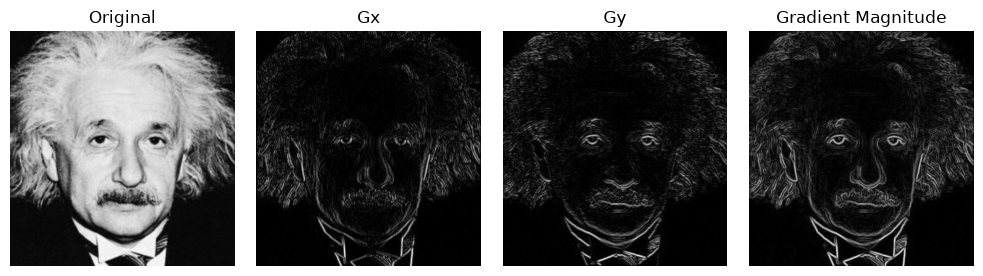

In [81]:
# Sobel kernels
Gx_kernel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

Gy_kernel = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

# Apply Sobel filtering using filter2D
Gx = cv2.filter2D(image, cv2.CV_64F, Gx_kernel)
Gy = cv2.filter2D(image, cv2.CV_64F, Gy_kernel)

# Gradient magnitude
magnitude = np.sqrt(Gx**2 + Gy**2)

# Display
fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(np.abs(Gx), cmap="gray")
axes[1].set_title("Gx")
axes[1].axis("off")

axes[2].imshow(np.abs(Gy), cmap="gray")
axes[2].set_title("Gy")
axes[2].axis("off")

axes[3].imshow(magnitude, cmap="gray")
axes[3].set_title("Gradient Magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

#### 7.(b) Implementing the Sobel Filter

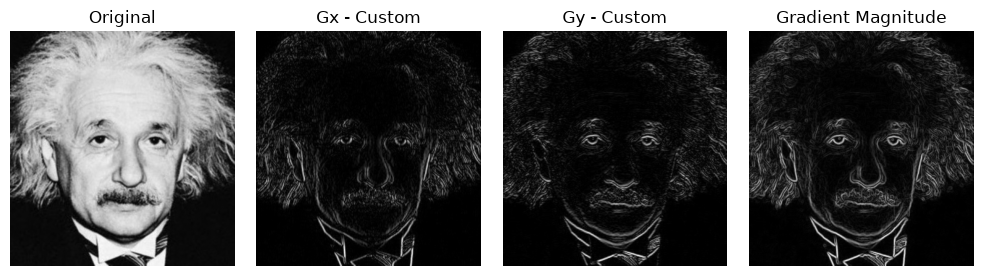

In [82]:
def sobel_filter(image, kernel):
    padded = np.pad(image, 1, mode="edge")
    output = np.zeros_like(image, dtype=np.float64)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)

    return output


# Apply custom Sobel filtering
Gx_custom = sobel_filter(image, Gx_kernel)
Gy_custom = sobel_filter(image, Gy_kernel)

# Gradient magnitude
magnitude_custom = np.sqrt(
    Gx_custom**2 + Gy_custom**2
)

# Display
fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(np.abs(Gx_custom), cmap="gray")
axes[1].set_title("Gx - Custom")
axes[1].axis("off")

axes[2].imshow(np.abs(Gy_custom), cmap="gray")
axes[2].set_title("Gy - Custom")
axes[2].axis("off")

axes[3].imshow(magnitude_custom, cmap="gray")
axes[3].set_title("Gradient Magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

#### 7.(c) Sobel Filtering Using Separable Kernels

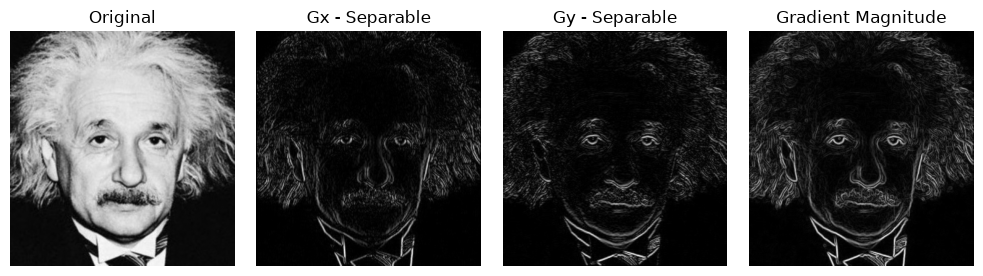

In [83]:
# 1D Sobel filters
smooth = np.array([1, 2, 1], dtype=np.float64)
derivative = np.array([1, 0, -1], dtype=np.float64)

# Gx = [1 2 1]^T * [1 0 -1]
temp = cv2.filter2D(
    image,
    cv2.CV_64F,
    smooth.reshape(-1, 1)
)

Gx_sep = cv2.filter2D(
    temp,
    cv2.CV_64F,
    derivative.reshape(1, -1)
)

# Gy = [1 2 1] * [1 0 -1]^T
temp = cv2.filter2D(
    image,
    cv2.CV_64F,
    smooth.reshape(1, -1)
)

Gy_sep = cv2.filter2D(
    temp,
    cv2.CV_64F,
    derivative.reshape(-1, 1)
)

# Gradient magnitude
magnitude_sep = np.sqrt(
    Gx_sep**2 + Gy_sep**2
)

# Display
fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(np.abs(Gx_sep), cmap="gray")
axes[1].set_title("Gx - Separable")
axes[1].axis("off")

axes[2].imshow(np.abs(Gy_sep), cmap="gray")
axes[2].set_title("Gy - Separable")
axes[2].axis("off")

axes[3].imshow(magnitude_sep, cmap="gray")
axes[3].set_title("Gradient Magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

**Observation:** The (G_x) and (G_y) images highlight intensity changes in the horizontal and vertical directions, respectively. The gradient magnitude combines these responses and clearly emphasizes the edges in the image. The results from the three implementations are visually very similar, confirming that the custom and separable implementations correctly reproduce the Sobel filtering operation.